<a href="https://colab.research.google.com/github/SanjnaGujral5/fl_based_intrusion_detection_system/blob/main/ZeroDayAttack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# ============================================================
# CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from xgboost import XGBClassifier
from tabulate import tabulate

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# ============================================================
# CELL 3 — Load & Group Data (3-class labelling)
# ============================================================
train_file = "/content/drive/MyDrive/FL_IDS/UNSW_NB15_training-set.csv"
test_file  = "/content/drive/MyDrive/FL_IDS/UNSW_NB15_testing-set.csv"

df_train = pd.read_csv(train_file)
df_test  = pd.read_csv(test_file)
df       = pd.concat([df_train, df_test], ignore_index=True)

malware_attacks    = {"backdoor", "shellcode", "worms"}
ids_general_attacks = {"fuzzers", "analysis", "dos", "exploits", "generic", "reconnaissance"}

def map_attack_group(row):
    if "label" in row and row["label"] == 0:
        return "Normal"
    attack = str(row["attack_cat"]).strip().lower()
    if attack in malware_attacks:
        return "Malware"
    elif attack in ids_general_attacks:
        return "IDS-General"
    elif attack == "normal":
        return "Normal"
    else:
        return "Unknown"

df["group_label"] = df.apply(map_attack_group, axis=1)
df_final = df[df["group_label"] != "Unknown"].copy()

label_map = {"Normal": 0, "Malware": 1, "IDS-General": 2}
df_final["group_id"] = df_final["group_label"].map(label_map)

print(df_final["group_label"].value_counts())
print(df_final[["group_label", "group_id"]].drop_duplicates())

save_path = "/content/drive/MyDrive/FL_IDS/UNSW_NB15_grouped_3class.csv"
df_final.to_csv(save_path, index=False)
print(f"Saved: {save_path}")

group_label
IDS-General    160659
Normal          93000
Malware          4014
Name: count, dtype: int64
       group_label  group_id
0           Normal         0
47911      Malware         1
47932  IDS-General         2
Saved: /content/drive/MyDrive/FL_IDS/UNSW_NB15_grouped_3class.csv


In [4]:
# ============================================================
# CELL 4 — Create Branch Datasets
# ============================================================
df = pd.read_csv("/content/drive/MyDrive/FL_IDS/UNSW_NB15_grouped_3class.csv")
print(df.shape)
print(df["group_label"].value_counts())

df_malware = df[df["group_label"].isin(["Normal", "Malware"])].copy()
df_ids     = df[df["group_label"].isin(["Normal", "IDS-General"])].copy()

df_malware["binary_label"] = (df_malware["group_label"] == "Malware").astype(int)
df_ids["binary_label"]     = (df_ids["group_label"] == "IDS-General").astype(int)

print("Malware branch:\n", df_malware["group_label"].value_counts())
print("IDS branch:\n",     df_ids["group_label"].value_counts())

malware_path = "/content/drive/MyDrive/FL_IDS/UNSW_NB15_malware_branch.csv"
ids_path     = "/content/drive/MyDrive/FL_IDS/UNSW_NB15_ids_branch.csv"
df_malware.to_csv(malware_path, index=False)
df_ids.to_csv(ids_path, index=False)
print("Saved malware branch:", malware_path)
print("Saved IDS branch:",     ids_path)

(257673, 47)
group_label
IDS-General    160659
Normal          93000
Malware          4014
Name: count, dtype: int64
Malware branch:
 group_label
Normal     93000
Malware     4014
Name: count, dtype: int64
IDS branch:
 group_label
IDS-General    160659
Normal          93000
Name: count, dtype: int64
Saved malware branch: /content/drive/MyDrive/FL_IDS/UNSW_NB15_malware_branch.csv
Saved IDS branch: /content/drive/MyDrive/FL_IDS/UNSW_NB15_ids_branch.csv


In [20]:


# ============================================================
# CELL 5 — Preprocessing (split / encode / scale)
# ============================================================
df_malware = pd.read_csv("/content/drive/MyDrive/FL_IDS/UNSW_NB15_malware_branch.csv")
df_ids     = pd.read_csv("/content/drive/MyDrive/FL_IDS/UNSW_NB15_ids_branch.csv")

drop_cols = ["id", "attack_cat", "label", "group_id", "group_label"]

X_m = df_malware.drop(columns=[c for c in drop_cols if c in df_malware.columns] + ["binary_label"])
y_m = df_malware["binary_label"]

X_i = df_ids.drop(columns=[c for c in drop_cols if c in df_ids.columns] + ["binary_label"])
y_i = df_ids["binary_label"]

# --- Train / Val / Test split (70 / 15 / 15) ---
X_m_train, X_m_temp, y_m_train, y_m_temp = train_test_split(
    X_m, y_m, test_size=0.30, random_state=42, stratify=y_m)
X_m_val, X_m_test, y_m_val, y_m_test = train_test_split(
    X_m_temp, y_m_temp, test_size=0.50, random_state=42, stratify=y_m_temp)

X_i_train, X_i_temp, y_i_train, y_i_temp = train_test_split(
    X_i, y_i, test_size=0.30, random_state=42, stratify=y_i)
X_i_val, X_i_test, y_i_val, y_i_test = train_test_split(
    X_i_temp, y_i_temp, test_size=0.50, random_state=42, stratify=y_i_temp)

print("Malware train/val/test:", X_m_train.shape, X_m_val.shape, X_m_test.shape)
print("IDS     train/val/test:", X_i_train.shape, X_i_val.shape, X_i_test.shape)

# --- One-hot encode & align columns ---
def one_hot_align(train_df, val_df, test_df):
    train_enc = pd.get_dummies(train_df, drop_first=True)
    val_enc   = pd.get_dummies(val_df,   drop_first=True)
    test_enc  = pd.get_dummies(test_df,  drop_first=True)
    val_enc   = val_enc.reindex(columns=train_enc.columns, fill_value=0)
    test_enc  = test_enc.reindex(columns=train_enc.columns, fill_value=0)
    # Force all columns to float32 — prevents "Invalid dtype: object" in Keras
    train_enc = train_enc.astype(np.float32)
    val_enc   = val_enc.astype(np.float32)
    test_enc  = test_enc.astype(np.float32)
    return train_enc, val_enc, test_enc

X_m_train_enc, X_m_val_enc, X_m_test_enc = one_hot_align(X_m_train, X_m_val, X_m_test)
X_i_train_enc, X_i_val_enc, X_i_test_enc = one_hot_align(X_i_train, X_i_val, X_i_test)

# --- StandardScale (fit on train only) ---
def scale_data(train_df, val_df, test_df):
    scaler = StandardScaler()
    train_s = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns, index=train_df.index)
    val_s   = pd.DataFrame(scaler.transform(val_df),       columns=val_df.columns,   index=val_df.index)
    test_s  = pd.DataFrame(scaler.transform(test_df),      columns=test_df.columns,  index=test_df.index)
    return train_s, val_s, test_s, scaler

X_m_train_scaled, X_m_val_scaled, X_m_test_scaled, scaler_m = scale_data(
    X_m_train_enc, X_m_val_enc, X_m_test_enc)
X_i_train_scaled, X_i_val_scaled, X_i_test_scaled, scaler_i = scale_data(
    X_i_train_enc, X_i_val_enc, X_i_test_enc)

print("Scaled Malware train:", X_m_train_scaled.shape)
print("Scaled IDS train:",     X_i_train_scaled.shape)

Malware train/val/test: (67909, 42) (14552, 42) (14553, 42)
IDS     train/val/test: (177561, 42) (38049, 42) (38049, 42)
Scaled Malware train: (67909, 185)
Scaled IDS train: (177561, 189)


In [21]:
# ============================================================
# CELL 6 — Feature Selection Functions (5 methods)
# ============================================================
TOP_K = 20

def select_features_chi2(X_train, y_train, k=TOP_K):
    scaler   = MinMaxScaler()
    X_nonneg = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    selector = SelectKBest(score_func=chi2, k=min(k, X_train.shape[1]))
    selector.fit(X_nonneg, y_train)
    selected = X_train.columns[selector.get_support()].tolist()
    scores   = pd.Series(selector.scores_, index=X_train.columns).sort_values(ascending=False)
    return selected, scores

def select_features_rf(X_train, y_train, k=TOP_K):
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    scores   = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    selected = scores.head(k).index.tolist()
    return selected, scores

def select_features_svm(X_train, y_train, k=TOP_K):
    scaler   = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    svm      = LinearSVC(C=1.0, penalty='l2', dual=False, max_iter=5000)
    svm.fit(X_scaled, y_train)
    importance = np.abs(svm.coef_).mean(axis=0)
    scores     = pd.Series(importance, index=X_train.columns).sort_values(ascending=False)
    selected   = scores.head(min(k, X_train.shape[1])).index.tolist()
    return selected, scores

def select_features_xgb(X_train, y_train, k=TOP_K):
    model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1,
        use_label_encoder=False, eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    scores   = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    selected = scores.head(min(k, X_train.shape[1])).index.tolist()
    return selected, scores

def select_features_pca(X_train, y_train=None, k=TOP_K):
    scaler   = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    pca      = PCA(random_state=42)
    pca.fit(X_scaled)
    loadings   = pca.components_
    variance   = pca.explained_variance_ratio_
    importance = np.sum((loadings ** 2) * variance[:, np.newaxis], axis=0)
    scores     = pd.Series(importance, index=X_train.columns).sort_values(ascending=False)
    selected   = scores.head(min(k, X_train.shape[1])).index.tolist()
    return selected, scores

In [22]:
# ============================================================
# CELL 7 — Run Feature Selection for All 5 Clients
# ============================================================
# Client 1 — Chi-square
c1_malware_features, _ = select_features_chi2(X_m_train_scaled, y_m_train)
c1_ids_features, _     = select_features_chi2(X_i_train_scaled, y_i_train)
print("C1 Malware (Chi2):", c1_malware_features[:10])
print("C1 IDS     (Chi2):", c1_ids_features[:10])

# Client 2 — Random Forest
c2_malware_features, _ = select_features_rf(X_m_train_scaled, y_m_train)
c2_ids_features, _     = select_features_rf(X_i_train_scaled, y_i_train)
print("C2 Malware (RF):", c2_malware_features[:10])
print("C2 IDS     (RF):", c2_ids_features[:10])

# Client 3 — SVM
c3_malware_features, _ = select_features_svm(X_m_train_scaled, y_m_train)
c3_ids_features, _     = select_features_svm(X_i_train_scaled, y_i_train)
print("C3 Malware (SVM):", c3_malware_features[:10])
print("C3 IDS     (SVM):", c3_ids_features[:10])

# Client 4 — XGBoost
c4_malware_features, _ = select_features_xgb(X_m_train_scaled, y_m_train)
c4_ids_features, _     = select_features_xgb(X_i_train_scaled, y_i_train)
print("C4 Malware (XGB):", c4_malware_features[:10])
print("C4 IDS     (XGB):", c4_ids_features[:10])

# Client 5 — PCA
c5_malware_features, _ = select_features_pca(X_m_train_scaled, y_m_train)
c5_ids_features, _     = select_features_pca(X_i_train_scaled, y_i_train)
print("C5 Malware (PCA):", c5_malware_features[:10])
print("C5 IDS     (PCA):", c5_ids_features[:10])

C1 Malware (Chi2): ['rate', 'sttl', 'dload', 'swin', 'stcpb', 'dtcpb', 'dwin', 'dmean', 'ct_state_ttl', 'proto_any']
C1 IDS     (Chi2): ['rate', 'sttl', 'dload', 'swin', 'stcpb', 'dtcpb', 'dwin', 'dmean', 'ct_state_ttl', 'ct_src_dport_ltm']
C2 Malware (RF): ['smean', 'sbytes', 'sload', 'proto_udp', 'ct_dst_src_ltm', 'ct_srv_dst', 'proto_unas', 'ct_dst_sport_ltm', 'dur', 'rate']
C2 IDS     (RF): ['sttl', 'ct_state_ttl', 'sload', 'dttl', 'sbytes', 'dload', 'dbytes', 'dmean', 'rate', 'ct_dst_src_ltm']
C3 Malware (SVM): ['dpkts', 'proto_tcp', 'dbytes', 'proto_udp', 'dinpkt', 'spkts', 'ct_src_dport_ltm', 'sloss', 'proto_arp', 'service_dns']
C3 IDS     (SVM): ['dttl', 'proto_tcp', 'dload', 'dbytes', 'dpkts', 'service_dns', 'dmean', 'sbytes', 'state_CON', 'dloss']


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:40:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:40:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C4 Malware (XGB): ['proto_unas', 'sttl', 'ct_dst_src_ltm', 'ct_dst_sport_ltm', 'proto_tcp', 'dinpkt', 'proto_ospf', 'proto_udp', 'swin', 'sloss']
C4 IDS     (XGB): ['sttl', 'dttl', 'ct_state_ttl', 'proto_arp', 'swin', 'ct_dst_sport_ltm', 'dload', 'service_dns', 'state_INT', 'ct_srv_dst']
C5 Malware (PCA): ['state_PAR', 'proto_wb-expak', 'proto_pipe', 'service_ftp', 'proto_a/n', 'is_sm_ips_ports', 'proto_arp', 'proto_ipv6-no', 'proto_sctp', 'proto_ib']
C5 IDS     (PCA): ['proto_compaq-peer', 'proto_mux', 'proto_dgp', 'proto_iso-tp4', 'proto_narp', 'proto_leaf-1', 'proto_pup', 'proto_sun-nd', 'proto_nvp', 'proto_srp']


In [23]:
# ============================================================
# CELL 8 — Shared Helper Functions
# ============================================================
def build_autoencoder(input_dim, latent_dim=8):
    inp     = layers.Input(shape=(input_dim,))
    x       = layers.Dense(64, activation='relu')(inp)
    x       = layers.Dense(32, activation='relu')(x)
    latent  = layers.Dense(latent_dim, activation='relu')(x)
    x       = layers.Dense(32, activation='relu')(latent)
    x       = layers.Dense(64, activation='relu')(x)
    out     = layers.Dense(input_dim, activation='linear')(x)
    model   = Model(inp, out)
    model.compile(optimizer='adam', loss='mse')
    return model

def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=1)

def normalize_scores(train_scores, val_scores, test_scores):
    mu    = np.mean(train_scores)
    sigma = np.std(train_scores) + 1e-8
    return (train_scores - mu) / sigma, (val_scores - mu) / sigma, (test_scores - mu) / sigma

def compute_threshold(normal_scores, quantile=0.999):
    return np.quantile(normal_scores, quantile)

def classification_metrics(y_true, y_pred, y_score=None):
    result = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        try:
            result["auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            result["auc"] = np.nan
    else:
        result["auc"] = np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    result["fpr"]  = fp / (fp + tn + 1e-8)
    return result

In [24]:
# ============================================================
# CELL 9 — Autoencoder Branch Training Function
# ============================================================
EPOCHS   = 10
QUANTILE = 0.946

def run_single_branch_ae(X_train_normal, X_val_normal, X_test_all, y_test,
                          features, quantile=QUANTILE, epochs=EPOCHS):
    X_tr_f  = X_train_normal[features].copy()
    X_val_f = X_val_normal[features].copy()
    X_te_f  = X_test_all[features].copy()

    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr_f)
    X_val_s = scaler.transform(X_val_f)
    X_te_s  = scaler.transform(X_te_f)

    model = build_autoencoder(
        input_dim=len(features),
        latent_dim=min(8, max(2, len(features) // 2))
    )
    model.fit(X_tr_s, X_tr_s, epochs=epochs, batch_size=256,
              verbose=0, validation_split=0.1)

    re_train = reconstruction_error(model, X_tr_s)
    re_val   = reconstruction_error(model, X_val_s)
    re_test  = reconstruction_error(model, X_te_s)

    _, re_val_n, re_test_n = normalize_scores(re_train, re_val, re_test)
    gamma  = compute_threshold(re_val_n, quantile=quantile)
    y_pred = (re_test_n > gamma).astype(int)
    metrics = classification_metrics(y_test, y_pred, re_test_n)

    return model, gamma, metrics, re_test_n

In [25]:
# ============================================================
# CELL 10 — XGBoost Branch Training Function
# ============================================================
def run_single_branch_xgb(X_train, X_val, X_test, y_train, y_val, y_test,
                           features, quantile=0.95):
    available = [f for f in features if f in X_train.columns]

    X_tr_f  = X_train[available].copy()
    X_val_f = X_val[available].copy()
    X_te_f  = X_test[available].copy()

    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr_f)
    X_val_s = scaler.transform(X_val_f)
    X_te_s  = scaler.transform(X_te_f)

    pos = np.sum(y_train)
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1

    model = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', use_label_encoder=False,
        scale_pos_weight=scale_pos_weight, random_state=42
    )
    model.fit(X_tr_s, y_train)

    prob_val        = model.predict_proba(X_val_s)[:, 1]
    prob_val_normal = prob_val[y_val == 0]
    gamma           = np.quantile(prob_val_normal, quantile)

    prob_test = model.predict_proba(X_te_s)[:, 1]
    y_pred    = (prob_test > gamma).astype(int)
    metrics   = classification_metrics(y_test, y_pred, prob_test)

    return model, scaler, gamma, metrics, prob_test

In [26]:
# ============================================================
# CELL 11 — Train Autoencoders for All 5 Clients
# ============================================================
print("Training Autoencoders — Client 1 (Chi-square)...")
model_c1_m, gamma_c1_m, metrics_c1_m, score_c1_m = run_single_branch_ae(
    X_m_train_scaled[y_m_train == 0], X_m_val_scaled[y_m_val == 0],
    X_m_test_scaled, y_m_test.values, c1_malware_features)
model_c1_i, gamma_c1_i, metrics_c1_i, score_c1_i = run_single_branch_ae(
    X_i_train_scaled[y_i_train == 0], X_i_val_scaled[y_i_val == 0],
    X_i_test_scaled, y_i_test.values, c1_ids_features)

print("Training Autoencoders — Client 2 (Random Forest)...")
model_c2_m, gamma_c2_m, metrics_c2_m, score_c2_m = run_single_branch_ae(
    X_m_train_scaled[y_m_train == 0], X_m_val_scaled[y_m_val == 0],
    X_m_test_scaled, y_m_test.values, c2_malware_features)
model_c2_i, gamma_c2_i, metrics_c2_i, score_c2_i = run_single_branch_ae(
    X_i_train_scaled[y_i_train == 0], X_i_val_scaled[y_i_val == 0],
    X_i_test_scaled, y_i_test.values, c2_ids_features)

print("Training Autoencoders — Client 3 (SVM)...")
model_c3_m, gamma_c3_m, metrics_c3_m, score_c3_m = run_single_branch_ae(
    X_m_train_scaled[y_m_train == 0], X_m_val_scaled[y_m_val == 0],
    X_m_test_scaled, y_m_test.values, c3_malware_features)
model_c3_i, gamma_c3_i, metrics_c3_i, score_c3_i = run_single_branch_ae(
    X_i_train_scaled[y_i_train == 0], X_i_val_scaled[y_i_val == 0],
    X_i_test_scaled, y_i_test.values, c3_ids_features)

print("Training Autoencoders — Client 4 (XGBoost features)...")
model_c4_m, gamma_c4_m, metrics_c4_m, score_c4_m = run_single_branch_ae(
    X_m_train_scaled[y_m_train == 0], X_m_val_scaled[y_m_val == 0],
    X_m_test_scaled, y_m_test.values, c4_malware_features)
model_c4_i, gamma_c4_i, metrics_c4_i, score_c4_i = run_single_branch_ae(
    X_i_train_scaled[y_i_train == 0], X_i_val_scaled[y_i_val == 0],
    X_i_test_scaled, y_i_test.values, c4_ids_features)

print("Training Autoencoders — Client 5 (PCA)...")
model_c5_m, gamma_c5_m, metrics_c5_m, score_c5_m = run_single_branch_ae(
    X_m_train_scaled[y_m_train == 0], X_m_val_scaled[y_m_val == 0],
    X_m_test_scaled, y_m_test.values, c5_malware_features)
model_c5_i, gamma_c5_i, metrics_c5_i, score_c5_i = run_single_branch_ae(
    X_i_train_scaled[y_i_train == 0], X_i_val_scaled[y_i_val == 0],
    X_i_test_scaled, y_i_test.values, c5_ids_features)

print("All Autoencoder models trained.")

Training Autoencoders — Client 1 (Chi-square)...
Training Autoencoders — Client 2 (Random Forest)...
Training Autoencoders — Client 3 (SVM)...
Training Autoencoders — Client 4 (XGBoost features)...
Training Autoencoders — Client 5 (PCA)...
All Autoencoder models trained.


In [27]:
# ============================================================
# CELL 12 — Train XGBoost for All 5 Clients
# ============================================================
print("Training XGBoost — Client 1...")
model_c1_m_xgb, scaler_c1_m_xgb, gamma_c1_m_xgb, metrics_c1_m_xgb, score_c1_m_xgb = run_single_branch_xgb(
    X_m_train_enc, X_m_val_enc, X_m_test_enc, y_m_train, y_m_val, y_m_test.values, c1_malware_features)
model_c1_i_xgb, scaler_c1_i_xgb, gamma_c1_i_xgb, metrics_c1_i_xgb, score_c1_i_xgb = run_single_branch_xgb(
    X_i_train_enc, X_i_val_enc, X_i_test_enc, y_i_train, y_i_val, y_i_test.values, c1_ids_features)

print("Training XGBoost — Client 2...")
model_c2_m_xgb, scaler_c2_m_xgb, gamma_c2_m_xgb, metrics_c2_m_xgb, score_c2_m_xgb = run_single_branch_xgb(
    X_m_train_enc, X_m_val_enc, X_m_test_enc, y_m_train, y_m_val, y_m_test.values, c2_malware_features)
model_c2_i_xgb, scaler_c2_i_xgb, gamma_c2_i_xgb, metrics_c2_i_xgb, score_c2_i_xgb = run_single_branch_xgb(
    X_i_train_enc, X_i_val_enc, X_i_test_enc, y_i_train, y_i_val, y_i_test.values, c2_ids_features)

print("Training XGBoost — Client 3...")
model_c3_m_xgb, scaler_c3_m_xgb, gamma_c3_m_xgb, metrics_c3_m_xgb, score_c3_m_xgb = run_single_branch_xgb(
    X_m_train_enc, X_m_val_enc, X_m_test_enc, y_m_train, y_m_val, y_m_test.values, c3_malware_features)
model_c3_i_xgb, scaler_c3_i_xgb, gamma_c3_i_xgb, metrics_c3_i_xgb, score_c3_i_xgb = run_single_branch_xgb(
    X_i_train_enc, X_i_val_enc, X_i_test_enc, y_i_train, y_i_val, y_i_test.values, c3_ids_features)

print("Training XGBoost — Client 4...")
model_c4_m_xgb, scaler_c4_m_xgb, gamma_c4_m_xgb, metrics_c4_m_xgb, score_c4_m_xgb = run_single_branch_xgb(
    X_m_train_enc, X_m_val_enc, X_m_test_enc, y_m_train, y_m_val, y_m_test.values, c4_malware_features)
model_c4_i_xgb, scaler_c4_i_xgb, gamma_c4_i_xgb, metrics_c4_i_xgb, score_c4_i_xgb = run_single_branch_xgb(
    X_i_train_enc, X_i_val_enc, X_i_test_enc, y_i_train, y_i_val, y_i_test.values, c4_ids_features)

print("Training XGBoost — Client 5...")
model_c5_m_xgb, scaler_c5_m_xgb, gamma_c5_m_xgb, metrics_c5_m_xgb, score_c5_m_xgb = run_single_branch_xgb(
    X_m_train_enc, X_m_val_enc, X_m_test_enc, y_m_train, y_m_val, y_m_test.values, c5_malware_features)
model_c5_i_xgb, scaler_c5_i_xgb, gamma_c5_i_xgb, metrics_c5_i_xgb, score_c5_i_xgb = run_single_branch_xgb(
    X_i_train_enc, X_i_val_enc, X_i_test_enc, y_i_train, y_i_val, y_i_test.values, c5_ids_features)

print("All XGBoost models trained.")

Training XGBoost — Client 1...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training XGBoost — Client 2...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training XGBoost — Client 3...


...

Training XGBoost — Client 4...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training XGBoost — Client 5...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


All XGBoost models trained.


In [28]:
# ============================================================
# CELL 13 — Build Full Dataset for Decision Engine
# ============================================================
df_full = pd.read_csv("/content/drive/MyDrive/FL_IDS/UNSW_NB15_grouped_3class.csv")

# Binary label: Normal=0, any attack=1
df_full["final_binary_label"] = (df_full["group_label"] != "Normal").astype(int)
print(df_full["group_label"].value_counts())
print(df_full["final_binary_label"].value_counts())

drop_cols_full = ["id", "attack_cat", "label", "group_id", "group_label", "final_binary_label"]
X_full = df_full.drop(columns=[c for c in drop_cols_full if c in df_full.columns])
y_full = df_full["final_binary_label"]

X_full_train, X_full_temp, y_full_train, y_full_temp = train_test_split(
    X_full, y_full, test_size=0.30, random_state=42, stratify=y_full)
X_full_val, X_full_test, y_full_val, y_full_test = train_test_split(
    X_full_temp, y_full_temp, test_size=0.50, random_state=42, stratify=y_full_temp)

X_full_train_enc, X_full_val_enc, X_full_test_enc = one_hot_align(
    X_full_train, X_full_val, X_full_test)

print("Full train/val/test:", X_full_train_enc.shape,
      X_full_val_enc.shape, X_full_test_enc.shape)

group_label
IDS-General    160659
Normal          93000
Malware          4014
Name: count, dtype: int64
final_binary_label
1    164673
0     93000
Name: count, dtype: int64
Full train/val/test: (180371, 190) (38651, 190) (38651, 190)


In [29]:
# ============================================================
# CELL 14 — IMPROVED DECISION ENGINE (Class Definition)
# ============================================================

class ImprovedDecisionEngine:
    """
    Fuses Malware + IDS-General branches into one binary prediction.

    Strategies
    ----------
    'or'           : baseline OR-fusion (original approach)
    'weighted_avg' : val-calibrated weighted average + optimal threshold
    'stacking'     : logistic meta-classifier on branch scores (val-fitted)
    """

    def __init__(self, strategy="weighted_avg"):
        assert strategy in ("or", "weighted_avg", "stacking")
        self.strategy  = strategy
        self.w_m       = 0.5
        self.w_i       = 0.5
        self.threshold = 0.0
        self.meta_clf  = None

    # ----------------------------------------------------------
    def _get_ae_scores(self, model, X_train_normal, X_query, features):
        """Z-scored reconstruction error."""
        X_tr = X_train_normal[features].values
        X_q  = X_query[features].values
        re_tr = np.mean(np.square(X_tr - model.predict(X_tr, verbose=0)), axis=1)
        re_q  = np.mean(np.square(X_q  - model.predict(X_q,  verbose=0)), axis=1)
        mu, sigma = re_tr.mean(), re_tr.std() + 1e-8
        return (re_q - mu) / sigma

    def _get_xgb_scores(self, model, scaler, X_query, features):
        """Raw probability from XGBoost."""
        feat = [f for f in features if f in X_query.columns]
        return model.predict_proba(scaler.transform(X_query[feat]))[:, 1]

    # ----------------------------------------------------------
    def calibrate(self, score_m_val, score_i_val, y_val, gamma_m, gamma_i):
        """Fit fusion weights / threshold on validation labels."""
        y_val = np.asarray(y_val)

        if self.strategy == "or":
            return  # no calibration needed

        if self.strategy == "weighted_avg":
            best_f1, best_w, best_t = 0.0, 0.5, 0.0
            for w in np.linspace(0, 1, 21):
                combined = w * score_m_val + (1 - w) * score_i_val
                for t in np.percentile(combined, np.linspace(50, 99, 30)):
                    pred = (combined > t).astype(int)
                    f1   = f1_score(y_val, pred, zero_division=0)
                    if f1 > best_f1:
                        best_f1, best_w, best_t = f1, w, t
            self.w_m, self.w_i, self.threshold = best_w, 1 - best_w, best_t
            print(f"  [weighted_avg] w_m={self.w_m:.2f} w_i={self.w_i:.2f} "
                  f"thresh={self.threshold:.4f} val_F1={best_f1:.4f}")

        elif self.strategy == "stacking":
            from sklearn.linear_model import LogisticRegression
            X_meta = np.stack([score_m_val, score_i_val], axis=1)
            lr = LogisticRegression(C=1.0, max_iter=500, random_state=42)
            lr.fit(X_meta, y_val)
            self.meta_clf = lr
            print(f"  [stacking] coef={lr.coef_} intercept={lr.intercept_}")

    # ----------------------------------------------------------
    def predict(self, score_m_test, score_i_test, gamma_m, gamma_i):
        """Return (final_pred, final_score)."""
        if self.strategy == "or":
            pred_m = (score_m_test > gamma_m).astype(int)
            pred_i = (score_i_test > gamma_i).astype(int)
            final_pred  = ((pred_m == 1) | (pred_i == 1)).astype(int)
            final_score = np.maximum(score_m_test - gamma_m, score_i_test - gamma_i)
            return final_pred, final_score

        if self.strategy == "weighted_avg":
            combined   = self.w_m * score_m_test + self.w_i * score_i_test
            final_pred = (combined > self.threshold).astype(int)
            return final_pred, combined

        if self.strategy == "stacking":
            X_meta      = np.stack([score_m_test, score_i_test], axis=1)
            final_score = self.meta_clf.predict_proba(X_meta)[:, 1]
            final_pred  = (final_score > 0.5).astype(int)
            return final_pred, final_score

    # ----------------------------------------------------------
    def evaluate(self,
                 X_train_enc, X_val_enc, X_test_enc,
                 y_train, y_val, y_test,
                 malware_features, ids_features,
                 malware_model, ids_model,
                 gamma_m, gamma_i,
                 branch_type="autoencoder",
                 scaler_m=None, scaler_i=None):
        """Score → calibrate → predict → metrics. Returns full result dict."""
        y_train_arr = np.asarray(y_train)
        normal_mask = (y_train_arr == 0)

        if branch_type == "autoencoder":
            X_tr_norm_m = X_train_enc[malware_features][normal_mask]
            X_tr_norm_i = X_train_enc[ids_features][normal_mask]
            score_m_val  = self._get_ae_scores(malware_model, X_tr_norm_m, X_val_enc,  malware_features)
            score_m_test = self._get_ae_scores(malware_model, X_tr_norm_m, X_test_enc, malware_features)
            score_i_val  = self._get_ae_scores(ids_model,     X_tr_norm_i, X_val_enc,  ids_features)
            score_i_test = self._get_ae_scores(ids_model,     X_tr_norm_i, X_test_enc, ids_features)

        elif branch_type == "xgb":
            score_m_val  = self._get_xgb_scores(malware_model, scaler_m, X_val_enc,  malware_features)
            score_m_test = self._get_xgb_scores(malware_model, scaler_m, X_test_enc, malware_features)
            score_i_val  = self._get_xgb_scores(ids_model,     scaler_i, X_val_enc,  ids_features)
            score_i_test = self._get_xgb_scores(ids_model,     scaler_i, X_test_enc, ids_features)
        else:
            raise ValueError(f"Unknown branch_type: {branch_type}")

        self.calibrate(score_m_val, score_i_val, y_val, gamma_m, gamma_i)
        final_pred, final_score = self.predict(score_m_test, score_i_test, gamma_m, gamma_i)
        metrics = classification_metrics(np.asarray(y_test), final_pred, final_score)

        return {
            "metrics":     metrics,
            "final_pred":  final_pred,
            "final_score": final_score,
            "score_m":     score_m_test,
            "score_i":     score_i_test,
        }

In [30]:
# ============================================================
# CELL 15 — Alert Tiering Helper
# ============================================================

def classify_alert_tier(score_m, score_i, gamma_m, gamma_i):
    """
    Returns per-sample alert tier array:
      CRITICAL — both branches fire AND at least one is >2σ/prob above gamma
      HIGH     — both branches fire
      MEDIUM   — only one branch fires
      NORMAL   — neither fires
    """
    excess_m  = score_m - gamma_m
    excess_i  = score_i - gamma_i
    both_fire  = (excess_m > 0) & (excess_i > 0)
    either_hi  = (excess_m > 2.0) | (excess_i > 2.0)
    either_any = (excess_m > 0) | (excess_i > 0)

    tier = np.where(
        both_fire & either_hi, "CRITICAL",
        np.where(both_fire, "HIGH",
        np.where(either_any, "MEDIUM", "NORMAL"))
    )
    return tier

In [31]:
# ============================================================
# CELL 16 — FedAvg Aggregation Helpers
# ============================================================

def fedavg_thresholds(client_gammas, client_sizes):
    """Weighted average of (gamma_m, gamma_i) across clients."""
    sizes = np.array(client_sizes, dtype=float)
    total = sizes.sum()
    g_m = sum(s * g[0] for s, g in zip(sizes, client_gammas)) / total
    g_i = sum(s * g[1] for s, g in zip(sizes, client_gammas)) / total
    return g_m, g_i

def fedavg_engine_weights(engines, client_sizes):
    """Weighted average of branch weights from weighted_avg engines."""
    sizes = np.array(client_sizes, dtype=float)
    total = sizes.sum()
    w_m = sum(s * e.w_m for s, e in zip(sizes, engines)) / total
    w_i = sum(s * e.w_i for s, e in zip(sizes, engines)) / total
    thresh = sum(s * e.threshold for s, e in zip(sizes, engines)) / total
    return w_m, w_i, thresh

In [32]:

# ============================================================
# CELL 17 — Run All Clients: Autoencoder Decision Engine
#            (all 3 strategies compared per client)
# ============================================================

def run_client_decision_engine_ae(client_name, malware_features, ids_features,
                                   malware_model, ids_model, gamma_m, gamma_i):
    rows = []
    results = {}
    for strategy in ("or", "weighted_avg", "stacking"):
        engine = ImprovedDecisionEngine(strategy=strategy)
        result = engine.evaluate(
            X_full_train_enc, X_full_val_enc, X_full_test_enc,
            y_full_train, y_full_val, y_full_test,
            malware_features, ids_features,
            malware_model, ids_model,
            gamma_m, gamma_i,
            branch_type="autoencoder"
        )
        m = result["metrics"]
        rows.append([client_name, "AE", strategy,
                     round(m["accuracy"],4), round(m["precision"],4),
                     round(m["recall"],4),   round(m["f1"],4),
                     round(m["auc"],4),       round(m["fpr"],4)])
        results[strategy] = result
    return rows, results

headers = ["Client","Model","Strategy","Accuracy","Precision","Recall","F1","AUC","FPR"]
all_rows = []

print("\n=== AUTOENCODER DECISION ENGINE ===")
rows_c1_ae, res_c1_ae = run_client_decision_engine_ae(
    "client_1", c1_malware_features, c1_ids_features, model_c1_m, model_c1_i, gamma_c1_m, gamma_c1_i)
rows_c2_ae, res_c2_ae = run_client_decision_engine_ae(
    "client_2", c2_malware_features, c2_ids_features, model_c2_m, model_c2_i, gamma_c2_m, gamma_c2_i)
rows_c3_ae, res_c3_ae = run_client_decision_engine_ae(
    "client_3", c3_malware_features, c3_ids_features, model_c3_m, model_c3_i, gamma_c3_m, gamma_c3_i)
rows_c4_ae, res_c4_ae = run_client_decision_engine_ae(
    "client_4", c4_malware_features, c4_ids_features, model_c4_m, model_c4_i, gamma_c4_m, gamma_c4_i)
rows_c5_ae, res_c5_ae = run_client_decision_engine_ae(
    "client_5", c5_malware_features, c5_ids_features, model_c5_m, model_c5_i, gamma_c5_m, gamma_c5_i)

all_rows_ae = rows_c1_ae + rows_c2_ae + rows_c3_ae + rows_c4_ae + rows_c5_ae
print(tabulate(all_rows_ae, headers=headers, tablefmt="grid"))


=== AUTOENCODER DECISION ENGINE ===


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


  [weighted_avg] w_m=0.00 w_i=1.00 thresh=-0.9006 val_F1=0.3934


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


  [stacking] coef=[[ 0.        -0.4948017]] intercept=[0.44955906]
  [weighted_avg] w_m=0.30 w_i=0.70 thresh=-0.0756 val_F1=0.7440
  [stacking] coef=[[0.0287642  0.02830849]] intercept=[0.5705468]
  [weighted_avg] w_m=1.00 w_i=0.00 thresh=-0.1324 val_F1=0.4071
  [stacking] coef=[[  0.39203143 -24.33960651]] intercept=[-7.34383843]
  [weighted_avg] w_m=0.05 w_i=0.95 thresh=-0.0758 val_F1=0.7525
  [stacking] coef=[[0.00345443 0.05772971]] intercept=[0.57051938]
  [weighted_avg] w_m=0.05 w_i=0.95 thresh=0.0059 val_F1=0.6487
  [stacking] coef=[[3.33943779e-01 1.56505170e-04]] intercept=[0.45699404]
+----------+---------+--------------+------------+-------------+----------+--------+--------+--------+
| Client   | Model   | Strategy     |   Accuracy |   Precision |   Recall |     F1 |    AUC |    FPR |
+==========+=========+==============+============+=============+==========+========+========+========+
| client_1 | AE      | or           |     0.3452 |      0.4667 |   0.1717 | 0.251  | 0.41

In [33]:
# ============================================================
# CELL 18 — Run All Clients: XGBoost Decision Engine
# ============================================================

def run_client_decision_engine_xgb(client_name, malware_features, ids_features,
                                    malware_model, ids_model,
                                    scaler_m, scaler_i, gamma_m, gamma_i):
    rows = []
    results = {}
    for strategy in ("or", "weighted_avg", "stacking"):
        engine = ImprovedDecisionEngine(strategy=strategy)
        result = engine.evaluate(
            X_full_train_enc, X_full_val_enc, X_full_test_enc,
            y_full_train, y_full_val, y_full_test,
            malware_features, ids_features,
            malware_model, ids_model,
            gamma_m, gamma_i,
            branch_type="xgb",
            scaler_m=scaler_m, scaler_i=scaler_i
        )
        m = result["metrics"]
        rows.append([client_name, "XGB", strategy,
                     round(m["accuracy"],4), round(m["precision"],4),
                     round(m["recall"],4),   round(m["f1"],4),
                     round(m["auc"],4),       round(m["fpr"],4)])
        results[strategy] = result
    return rows, results

print("\n=== XGBoost DECISION ENGINE ===")
rows_c1_xgb, res_c1_xgb = run_client_decision_engine_xgb(
    "client_1", c1_malware_features, c1_ids_features,
    model_c1_m_xgb, model_c1_i_xgb, scaler_c1_m_xgb, scaler_c1_i_xgb, gamma_c1_m_xgb, gamma_c1_i_xgb)
rows_c2_xgb, res_c2_xgb = run_client_decision_engine_xgb(
    "client_2", c2_malware_features, c2_ids_features,
    model_c2_m_xgb, model_c2_i_xgb, scaler_c2_m_xgb, scaler_c2_i_xgb, gamma_c2_m_xgb, gamma_c2_i_xgb)
rows_c3_xgb, res_c3_xgb = run_client_decision_engine_xgb(
    "client_3", c3_malware_features, c3_ids_features,
    model_c3_m_xgb, model_c3_i_xgb, scaler_c3_m_xgb, scaler_c3_i_xgb, gamma_c3_m_xgb, gamma_c3_i_xgb)
rows_c4_xgb, res_c4_xgb = run_client_decision_engine_xgb(
    "client_4", c4_malware_features, c4_ids_features,
    model_c4_m_xgb, model_c4_i_xgb, scaler_c4_m_xgb, scaler_c4_i_xgb, gamma_c4_m_xgb, gamma_c4_i_xgb)
rows_c5_xgb, res_c5_xgb = run_client_decision_engine_xgb(
    "client_5", c5_malware_features, c5_ids_features,
    model_c5_m_xgb, model_c5_i_xgb, scaler_c5_m_xgb, scaler_c5_i_xgb, gamma_c5_m_xgb, gamma_c5_i_xgb)

all_rows_xgb = rows_c1_xgb + rows_c2_xgb + rows_c3_xgb + rows_c4_xgb + rows_c5_xgb
print(tabulate(all_rows_xgb, headers=headers, tablefmt="grid"))


=== XGBoost DECISION ENGINE ===
  [weighted_avg] w_m=0.00 w_i=1.00 thresh=0.6951 val_F1=0.8690
  [stacking] coef=[[0.54473365 8.54939756]] intercept=[-3.97128395]
  [weighted_avg] w_m=0.05 w_i=0.95 thresh=0.9411 val_F1=0.8768
  [stacking] coef=[[-0.1488409   9.13163548]] intercept=[-3.68547912]
  [weighted_avg] w_m=0.05 w_i=0.95 thresh=0.9261 val_F1=0.8773
  [stacking] coef=[[0.25001443 9.01855506]] intercept=[-3.69243672]
  [weighted_avg] w_m=0.05 w_i=0.95 thresh=0.9161 val_F1=0.8771
  [stacking] coef=[[1.2217931  8.32802394]] intercept=[-3.54530504]
  [weighted_avg] w_m=0.05 w_i=0.95 thresh=0.4953 val_F1=0.3206
  [stacking] coef=[[-0.44205538  6.19519754]] intercept=[-2.35803975]
+----------+---------+--------------+------------+-------------+----------+--------+--------+--------+
| Client   | Model   | Strategy     |   Accuracy |   Precision |   Recall |     F1 |    AUC |    FPR |
+==========+=========+==============+============+=============+==========+========+========+========+

In [34]:

# ============================================================
# CELL 19 — FedAvg: Aggregate Weighted-Avg Engines (AE)
# ============================================================
print("\n=== FedAvg Aggregation (Autoencoder / weighted_avg) ===")

# Build per-client engines (weighted_avg, already fitted above in res_*_ae)
# We re-run to get the fitted engine objects with calibrated weights
client_engines_ae = []
client_configs_ae = [
    (c1_malware_features, c1_ids_features, model_c1_m, model_c1_i, gamma_c1_m, gamma_c1_i),
    (c2_malware_features, c2_ids_features, model_c2_m, model_c2_i, gamma_c2_m, gamma_c2_i),
    (c3_malware_features, c3_ids_features, model_c3_m, model_c3_i, gamma_c3_m, gamma_c3_i),
    (c4_malware_features, c4_ids_features, model_c4_m, model_c4_i, gamma_c4_m, gamma_c4_i),
    (c5_malware_features, c5_ids_features, model_c5_m, model_c5_i, gamma_c5_m, gamma_c5_i),
]
# Use actual training set sizes as client weights
client_sizes = [
    int((y_m_train == 0).sum()),   # normal-only training samples per client
    int((y_m_train == 0).sum()),
    int((y_m_train == 0).sum()),
    int((y_m_train == 0).sum()),
    int((y_m_train == 0).sum()),
]

for (mf, if_, mm, im, gm, gi) in client_configs_ae:
    eng = ImprovedDecisionEngine(strategy="weighted_avg")
    eng.evaluate(
        X_full_train_enc, X_full_val_enc, X_full_test_enc,
        y_full_train, y_full_val, y_full_test,
        mf, if_, mm, im, gm, gi,
        branch_type="autoencoder"
    )
    client_engines_ae.append(eng)

# FedAvg: aggregate weights and threshold
global_w_m, global_w_i, global_thresh = fedavg_engine_weights(client_engines_ae, client_sizes)
print(f"Global FedAvg: w_m={global_w_m:.3f}, w_i={global_w_i:.3f}, threshold={global_thresh:.4f}")

# Apply global weights to get global predictions on test set
# Use client_1 models as representative for demo (in real FL server would hold global model)
global_engine = ImprovedDecisionEngine(strategy="weighted_avg")
global_engine.w_m       = global_w_m
global_engine.w_i       = global_w_i
global_engine.threshold = global_thresh

# Score using client 1 models
score_m_global = global_engine._get_ae_scores(
    model_c1_m,
    X_full_train_enc[c1_malware_features][np.asarray(y_full_train) == 0],
    X_full_test_enc, c1_malware_features
)
score_i_global = global_engine._get_ae_scores(
    model_c1_i,
    X_full_train_enc[c1_ids_features][np.asarray(y_full_train) == 0],
    X_full_test_enc, c1_ids_features
)
global_pred, global_score = global_engine.predict(
    score_m_global, score_i_global, gamma_c1_m, gamma_c1_i)
global_metrics = classification_metrics(np.asarray(y_full_test), global_pred, global_score)
print("\nGlobal FedAvg Engine Metrics (AE):")
print(tabulate([list(global_metrics.values())],
               headers=list(global_metrics.keys()), tablefmt="grid"))


=== FedAvg Aggregation (Autoencoder / weighted_avg) ===


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


  [weighted_avg] w_m=0.00 w_i=1.00 thresh=-0.9006 val_F1=0.3934
  [weighted_avg] w_m=0.30 w_i=0.70 thresh=-0.0756 val_F1=0.7440
  [weighted_avg] w_m=1.00 w_i=0.00 thresh=-0.1324 val_F1=0.4071
  [weighted_avg] w_m=0.05 w_i=0.95 thresh=-0.0758 val_F1=0.7525
  [weighted_avg] w_m=0.05 w_i=0.95 thresh=0.0059 val_F1=0.6487
Global FedAvg: w_m=0.280, w_i=0.720, threshold=-0.2357


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)



Global FedAvg Engine Metrics (AE):
+------------+-------------+----------+----------+----------+----------+
|   accuracy |   precision |   recall |       f1 |      auc |      fpr |
+============+=============+==========+==========+==========+==========+
|   0.337637 |    0.465753 | 0.247763 | 0.323459 | 0.275569 | 0.503226 |
+------------+-------------+----------+----------+----------+----------+



DECISION ENGINE — FULL RESULTS (All Clients x All Models x All Strategies)
+----------+--------------+---------+--------------+------------+-------------+----------+--------+--------+--------+
| Client   | Features     | Model   | Strategy     |   Accuracy |   Precision |   Recall |     F1 |    AUC |    FPR |
+==========+==============+=========+==============+============+=============+==========+========+========+========+
| client_1 | Chi-square   | AE      | or           |     0.3452 |      0.4667 |   0.1717 | 0.251  | 0.4125 | 0.3475 |
+----------+--------------+---------+--------------+------------+-------------+----------+--------+--------+--------+
| client_1 | Chi-square   | AE      | weighted_avg |     0.3283 |      0.4647 |   0.3357 | 0.3898 | 0.2756 | 0.6848 |
+----------+--------------+---------+--------------+------------+-------------+----------+--------+--------+--------+
| client_1 | Chi-square   | AE      | stacking     |     0.6477 |      0.6645 |   0.9061 | 0.7668 

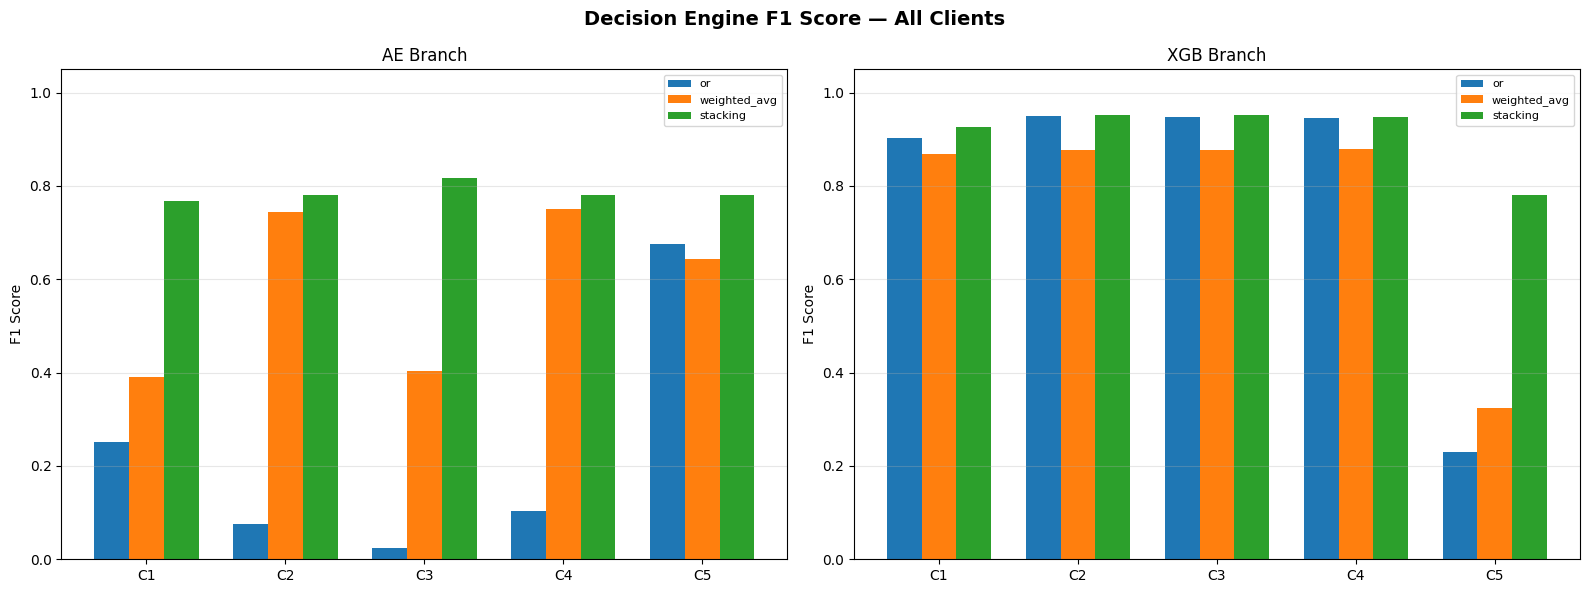

Saved: /content/drive/MyDrive/FL_IDS/results/f1_bar_chart.png


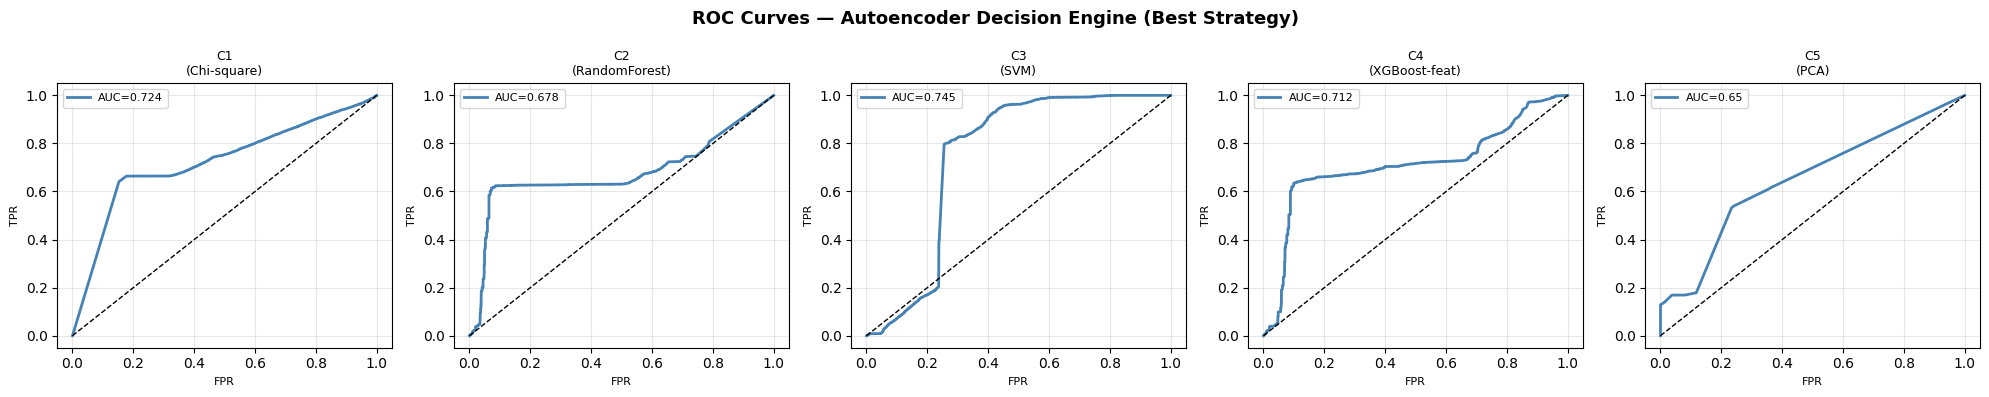

Saved: /content/drive/MyDrive/FL_IDS/results/roc_curves_ae.png


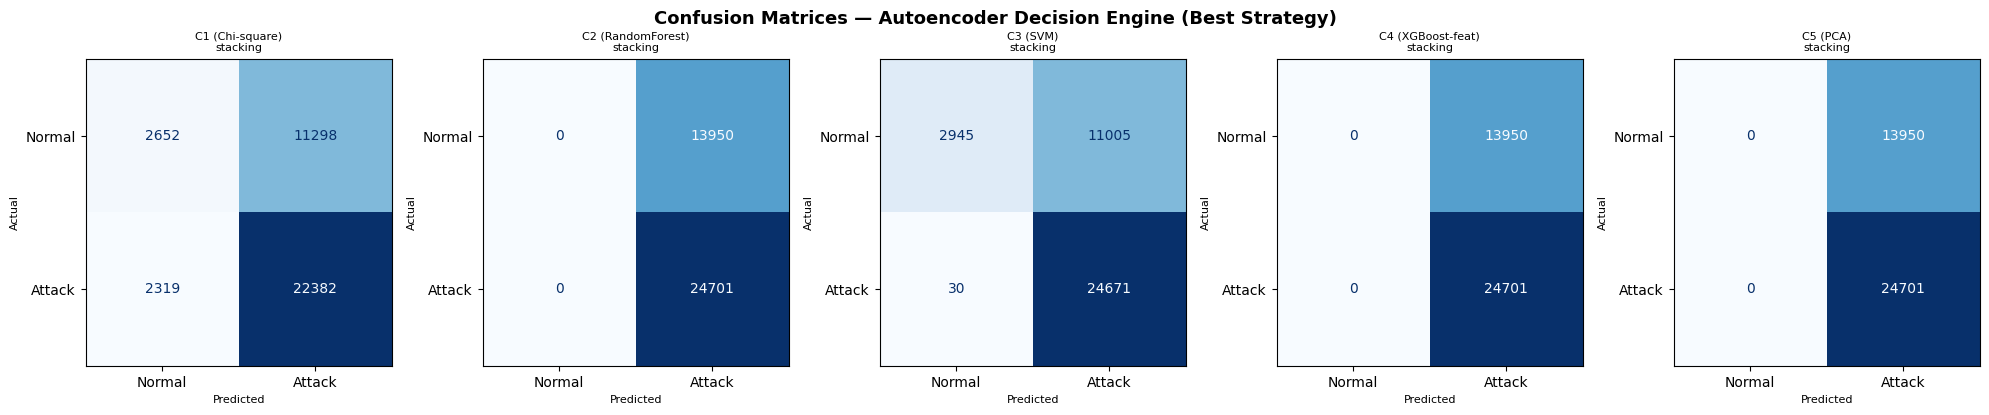

Saved: /content/drive/MyDrive/FL_IDS/results/confusion_matrices_ae.png


/tmp/ipykernel_4895/2245720235.py:205: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace("client_","Client ") for c in client_labels])


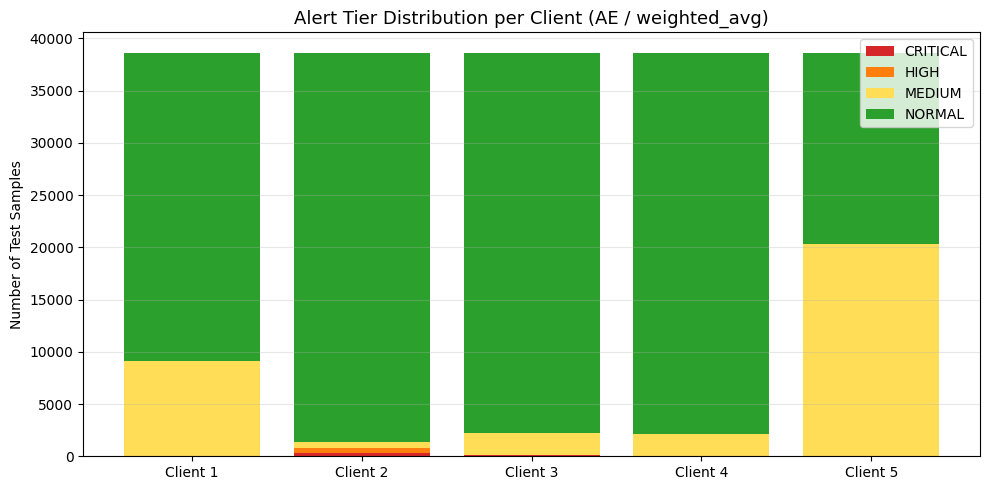

Saved: /content/drive/MyDrive/FL_IDS/results/alert_tier_distribution.png

PROJECT COMPLETE — All outputs saved to Google Drive:
  /content/drive/MyDrive/FL_IDS/results/decision_engine_full_results.csv
  /content/drive/MyDrive/FL_IDS/results/decision_engine_best_summary.csv
  /content/drive/MyDrive/FL_IDS/results/alert_tier_distribution.csv
  /content/drive/MyDrive/FL_IDS/results/fedavg_global_metrics.csv
  /content/drive/MyDrive/FL_IDS/results/f1_bar_chart.png
  /content/drive/MyDrive/FL_IDS/results/roc_curves_ae.png
  /content/drive/MyDrive/FL_IDS/results/confusion_matrices_ae.png
  /content/drive/MyDrive/FL_IDS/results/alert_tier_distribution.png


In [36]:
# ============================================================
# CELL 21 — Complete Final Output, Plots & Save Everything
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay
import os

SAVE_DIR = "/content/drive/MyDrive/FL_IDS/results/"
os.makedirs(SAVE_DIR, exist_ok=True)

client_map = {
    "client_1": ("Chi-square",   res_c1_ae, res_c1_xgb, c1_malware_features, c1_ids_features, gamma_c1_m, gamma_c1_i),
    "client_2": ("RandomForest", res_c2_ae, res_c2_xgb, c2_malware_features, c2_ids_features, gamma_c2_m, gamma_c2_i),
    "client_3": ("SVM",          res_c3_ae, res_c3_xgb, c3_malware_features, c3_ids_features, gamma_c3_m, gamma_c3_i),
    "client_4": ("XGBoost-feat", res_c4_ae, res_c4_xgb, c4_malware_features, c4_ids_features, gamma_c4_m, gamma_c4_i),
    "client_5": ("PCA",          res_c5_ae, res_c5_xgb, c5_malware_features, c5_ids_features, gamma_c5_m, gamma_c5_i),
}

y_test_arr = np.asarray(y_full_test)

# ------------------------------------------------------------------
# 1. FULL DECISION ENGINE RESULTS — all clients, all strategies
# ------------------------------------------------------------------
all_detail_rows = []
detail_headers  = ["Client","Features","Model","Strategy","Accuracy","Precision","Recall","F1","AUC","FPR"]

for client, (feat, ae_res, xgb_res, mf, if_, gm, gi) in client_map.items():
    for model_type, res in [("AE", ae_res), ("XGB", xgb_res)]:
        for strategy in ("or", "weighted_avg", "stacking"):
            m = res[strategy]["metrics"]
            all_detail_rows.append([
                client, feat, model_type, strategy,
                round(m["accuracy"],4), round(m["precision"],4),
                round(m["recall"],4),   round(m["f1"],4),
                round(m["auc"],4),      round(m["fpr"],4)
            ])

print("\n" + "="*80)
print("DECISION ENGINE — FULL RESULTS (All Clients x All Models x All Strategies)")
print("="*80)
print(tabulate(all_detail_rows, headers=detail_headers, tablefmt="grid"))

detail_df = pd.DataFrame(all_detail_rows, columns=detail_headers)
detail_df.to_csv(SAVE_DIR + "decision_engine_full_results.csv", index=False)
print(f"\nSaved: {SAVE_DIR}decision_engine_full_results.csv")

# ------------------------------------------------------------------
# 2. BEST STRATEGY SUMMARY — one row per client x model
# ------------------------------------------------------------------
summary_rows = []
summary_headers = ["Client","Features","Model","Best Strategy","Accuracy","Precision","Recall","F1","AUC","FPR"]

for client, (feat, ae_res, xgb_res, mf, if_, gm, gi) in client_map.items():
    for model_type, res in [("AE", ae_res), ("XGB", xgb_res)]:
        best_strategy = max(res, key=lambda s: res[s]["metrics"]["f1"])
        m = res[best_strategy]["metrics"]
        summary_rows.append([
            client, feat, model_type, best_strategy,
            round(m["accuracy"],4), round(m["precision"],4),
            round(m["recall"],4),   round(m["f1"],4),
            round(m["auc"],4),      round(m["fpr"],4)
        ])

print("\n" + "="*80)
print("DECISION ENGINE — BEST STRATEGY PER CLIENT")
print("="*80)
print(tabulate(summary_rows, headers=summary_headers, tablefmt="grid"))

summary_df = pd.DataFrame(summary_rows, columns=summary_headers)
summary_df.to_csv(SAVE_DIR + "decision_engine_best_summary.csv", index=False)
print(f"\nSaved: {SAVE_DIR}decision_engine_best_summary.csv")

# ------------------------------------------------------------------
# 3. ALERT TIER DISTRIBUTION — all clients, AE weighted_avg
# ------------------------------------------------------------------
print("\n" + "="*80)
print("ALERT TIER DISTRIBUTION (AE / weighted_avg)")
print("="*80)

tier_rows = []
all_tier_data = {}
for client, (feat, ae_res, xgb_res, mf, if_, gm, gi) in client_map.items():
    r = ae_res["weighted_avg"]
    tiers = classify_alert_tier(r["score_m"], r["score_i"], gm, gi)
    counts = pd.Series(tiers).value_counts()
    all_tier_data[client] = counts
    for tier_label in ["CRITICAL","HIGH","MEDIUM","NORMAL"]:
        count = int(counts.get(tier_label, 0))
        tier_rows.append([client, feat, tier_label, count])

print(tabulate(tier_rows, headers=["Client","Features","Tier","Count"], tablefmt="grid"))
tier_df = pd.DataFrame(tier_rows, columns=["Client","Features","Tier","Count"])
tier_df.to_csv(SAVE_DIR + "alert_tier_distribution.csv", index=False)
print(f"\nSaved: {SAVE_DIR}alert_tier_distribution.csv")

# ------------------------------------------------------------------
# 4. FEDAVG GLOBAL ENGINE RESULT
# ------------------------------------------------------------------
print("\n" + "="*80)
print("FEDAVG GLOBAL ENGINE METRICS (AE)")
print("="*80)
global_row = [[
    round(global_metrics["accuracy"],4), round(global_metrics["precision"],4),
    round(global_metrics["recall"],4),   round(global_metrics["f1"],4),
    round(global_metrics["auc"],4),      round(global_metrics["fpr"],4),
]]
print(tabulate(global_row, headers=["Accuracy","Precision","Recall","F1","AUC","FPR"], tablefmt="grid"))
fedavg_df = pd.DataFrame(global_row, columns=["Accuracy","Precision","Recall","F1","AUC","FPR"])
fedavg_df.to_csv(SAVE_DIR + "fedavg_global_metrics.csv", index=False)
print(f"\nSaved: {SAVE_DIR}fedavg_global_metrics.csv")

# ------------------------------------------------------------------
# 5. PLOT 1 — F1 Bar Chart: All Clients x Models x Strategies
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Decision Engine F1 Score — All Clients", fontsize=14, fontweight="bold")

for ax, model_type in zip(axes, ["AE", "XGB"]):
    subset    = detail_df[detail_df["Model"] == model_type]
    clients   = list(client_map.keys())
    strategies = ["or", "weighted_avg", "stacking"]
    x     = np.arange(len(clients))
    width = 0.25
    for i, strategy in enumerate(strategies):
        f1_vals = [
            float(subset[(subset["Client"]==c) & (subset["Strategy"]==strategy)]["F1"].values[0])
            for c in clients
        ]
        ax.bar(x + i*width, f1_vals, width, label=strategy)
    ax.set_xticks(x + width)
    ax.set_xticklabels([c.replace("client_","C") for c in clients])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1 Score")
    ax.set_title(f"{model_type} Branch")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + "f1_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}f1_bar_chart.png")

# ------------------------------------------------------------------
# 6. PLOT 2 — ROC Curves: Best strategy per client (AE)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("ROC Curves — Autoencoder Decision Engine (Best Strategy)", fontsize=13, fontweight="bold")

for ax, (client, (feat, ae_res, xgb_res, mf, if_, gm, gi)) in zip(axes, client_map.items()):
    best_strategy = max(ae_res, key=lambda s: ae_res[s]["metrics"]["f1"])
    r = ae_res[best_strategy]
    fpr_arr, tpr_arr, _ = roc_curve(y_test_arr, r["final_score"])
    auc_val = round(r["metrics"]["auc"], 3)
    ax.plot(fpr_arr, tpr_arr, color="steelblue", lw=2, label=f"AUC={auc_val}")
    ax.plot([0,1],[0,1],"k--", lw=1)
    ax.set_title(f"{client.replace('client_','C')}\n({feat})", fontsize=9)
    ax.set_xlabel("FPR", fontsize=8)
    ax.set_ylabel("TPR", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + "roc_curves_ae.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}roc_curves_ae.png")

# ------------------------------------------------------------------
# 7. PLOT 3 — Confusion Matrices: Best strategy per client (AE)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Confusion Matrices — Autoencoder Decision Engine (Best Strategy)", fontsize=13, fontweight="bold")

for ax, (client, (feat, ae_res, xgb_res, mf, if_, gm, gi)) in zip(axes, client_map.items()):
    best_strategy = max(ae_res, key=lambda s: ae_res[s]["metrics"]["f1"])
    r = ae_res[best_strategy]
    cm = confusion_matrix(y_test_arr, r["final_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal","Attack"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{client.replace('client_','C')} ({feat})\n{best_strategy}", fontsize=8)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_DIR + "confusion_matrices_ae.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}confusion_matrices_ae.png")

# ------------------------------------------------------------------
# 8. PLOT 4 — Alert Tier Stacked Bar Chart
# ------------------------------------------------------------------
tier_order  = ["CRITICAL","HIGH","MEDIUM","NORMAL"]
tier_colors = ["#d62728","#ff7f0e","#ffdd57","#2ca02c"]

fig, ax = plt.subplots(figsize=(10, 5))
client_labels = list(all_tier_data.keys())
bottoms = np.zeros(len(client_labels))

for tier_label, color in zip(tier_order, tier_colors):
    counts = [int(all_tier_data[c].get(tier_label, 0)) for c in client_labels]
    ax.bar(client_labels, counts, bottom=bottoms, label=tier_label, color=color)
    bottoms += np.array(counts)

ax.set_title("Alert Tier Distribution per Client (AE / weighted_avg)", fontsize=13)
ax.set_ylabel("Number of Test Samples")
ax.set_xticklabels([c.replace("client_","Client ") for c in client_labels])
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + "alert_tier_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}alert_tier_distribution.png")

# ------------------------------------------------------------------
# DONE
# ------------------------------------------------------------------
print("\n" + "="*80)
# print("PROJECT COMPLETE — All outputs saved to Google Drive:")
print(f"  {SAVE_DIR}decision_engine_full_results.csv")
print(f"  {SAVE_DIR}decision_engine_best_summary.csv")
print(f"  {SAVE_DIR}alert_tier_distribution.csv")
print(f"  {SAVE_DIR}fedavg_global_metrics.csv")
print(f"  {SAVE_DIR}f1_bar_chart.png")
print(f"  {SAVE_DIR}roc_curves_ae.png")
print(f"  {SAVE_DIR}confusion_matrices_ae.png")
print(f"  {SAVE_DIR}alert_tier_distribution.png")
print("="*80)
